In [2]:
import numpy as np
import scipy
import scipy.sparse
import numpy.linalg
import matplotlib.pyplot as plt

In [3]:
def G(x, t, n=3, a=1.0):
  arg = np.einsum("...i, ...i -> ...", x, x)[:,np.newaxis] / (4 * a * t)
  return (4 * np.pi * t)**(-n/2) * np.exp(-arg)

(0.9815400745695448, array([0.00625782]))

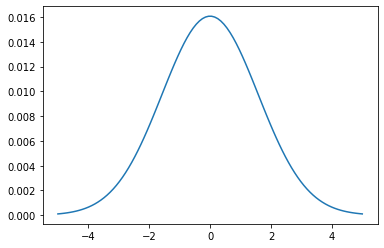

In [4]:
x_vec = np.linspace(-5, 5, 100)[:,np.newaxis]
dx = x_vec[1] - x_vec[0]
u_vec = G(x_vec , 1.25)
plt.plot(x_vec, u_vec)

x_vec = np.linspace(0, 5, 800)[:,np.newaxis]
dx = x_vec[1] - x_vec[0]
u_vec = G(x_vec , 1.25)

integrand = u_vec * 4*np.pi*np.abs(x_vec)**2 * dx
np.sum(integrand), dx


In [5]:
u_vec.shape

(800, 1)

### Spherically symmetric two-conductivity problem
$$
\rho c_p \partial_t - \frac{1}{r^2} \partial_r (r^2 k \partial_r )
$$

In [23]:
import scipy.special
from scipy.special import gammainc
from scipy.special import erf

#### 1D wall-transient

Homogeneous half-space 1D heat equation, with zero initial condition and boundary Dirichlet heaviside function:

In [ ]:
wall_transient_1D = lambda eta: 1 - gammainc(0.5, 0.25*eta)
wall_transient_spher = lambda eta: (1 -  erf(np.sqrt(0.25*eta))) \
    - 2 / np.sqrt(np.pi * eta) * np.exp(-0.25 * eta)


In [34]:
wall_transient_spher(1e-7)

-3567.2483215117477

In [40]:
wall_transient_1D(0)

1.0

Text(0.5, 0, '$x / \\sqrt{(\\alpha t )}$')

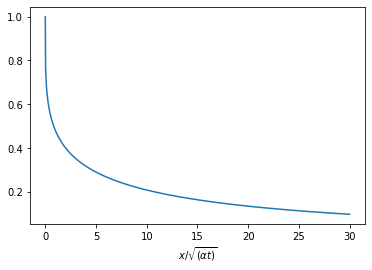

In [39]:
eta_range = np.linspace(0, 30, 1000)
plt.plot(eta_range, wall_transient_1D(np.sqrt(eta_range)))
plt.xlabel(r"$x / \sqrt{(\alpha t )}$")